**Author:** Brendan OConnell 

**Date:** May 2026  

**Purpose:** Baseline Model Exploration for XGBoost

**UPDATE**  

This XGBoost Baseline Model NB was retroactively created in the main feature pipeline, replacing `xgboost_baseline_v2.ipynb`, after several key findings took place between model exploration and model evaluation. These original engineered features were dropped:
- `core_gsr_count` feature appears to be a label proxy
- `log_pb_plus_sb` feature performed abysmally when evaluated against the ambiguous particle subset

Additionally, **all 89 raw elements** are now being used (tree models can handle sparsity and there may be some signal in there) along with **7 re-engineered features** (see `feature_engineering_xgb_all_elements.ipyng`) for a total of **96 features**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
)

# To properly execute this import be sure you have run steps 1 & 2 from the `docs/QuickStart.md` guide.
from src.xgb_nb_steps import xgb_feat_eng

> **Due to LFS data constraints, XGBoost notebooks won't be writing & loading parquets. Instead, the `src/xgb_nb_steps.py` module will be replicating each step in the notebook pipeline to load the proper dataset.**

### Load the NFI dataset to be used for XGBoost baseline model exploration

In [2]:
source_df = xgb_feat_eng()
source_df.shape

(2294985, 101)

In [3]:
# Verify column names
source_df.columns

Index(['stub_id', 'particle_id', 'class', 'label', 'target', 'ac', 'ag', 'al',
       'ar', 'as',
       ...
       'yb', 'zn', 'zr', 'pb_times_sb', 'pb_ba_over_non_sb_mass',
       'pb_sb_over_non_ba_mass', 'ba_sb_over_non_pb_mass', 'cu_zn_over_mass',
       'ti_zn_over_mass', 'gsr_over_confounders'],
      dtype='str', length=101)

In [4]:
meta_cols = ["stub_id", "particle_id", "class", "label", "target"]
feature_cols = [c for c in source_df.columns if c not in meta_cols]

print(f"# of Features: {len(feature_cols)}")

# of Features: 96


### Group aware train / test split 

**Critical**: The grouping sample is the *physical sample*, which is the stub_id for the NFI data. It is essential to use a Group Shuffle Split here so that no particles from the same stub id's end up in train & test sets.

Stratification preserves stub-level integrity.

**Two-stage GroupShuffleSplit:**
1. Split off 20% test (by stub_id)
2. From the remaining 80%, split off 25% as val (= 20% of total)

Result: 
**~60% train**
**~20% val**
**~20% test**

**No stub overlap between any pair.**

In [5]:
### Reproducibility: Set random seed
SEED = 42

In [6]:
X = source_df[feature_cols].values.astype(np.float32)
y = source_df["target"].values.astype(np.float32)
groups = source_df["stub_id"].values

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
trainval_idx, test_idx = next(gss1.split(X, y, groups))

X_trainval, X_test = X[trainval_idx], X[test_idx]
y_trainval, y_test = y[trainval_idx], y[test_idx]
groups_trainval = groups[trainval_idx]

gss2 = GroupShuffleSplit(
    n_splits=1, test_size=0.25, random_state=SEED
)  # 25% of 80% = 20% of total
train_idx_rel, val_idx_rel = next(gss2.split(X_trainval, y_trainval, groups_trainval))

X_train = X_trainval[train_idx_rel]
X_val = X_trainval[val_idx_rel]
y_train = y_trainval[train_idx_rel]
y_val = y_trainval[val_idx_rel]

groups_train = set(groups_trainval[train_idx_rel])
groups_val = set(groups_trainval[val_idx_rel])
groups_test = set(groups[test_idx])

**Verify no Stub Leakage**

In [7]:
assert len(groups_train & groups_val) == 0, "Train-Val stub leak!"
assert len(groups_train & groups_test) == 0, "Train-Test stub leak!"
assert len(groups_val & groups_test) == 0, "Val-Test stub leak!"

print("No stub-level leakage")

No stub-level leakage


**Summarize the Train / Val / Test split**

In [8]:
total_obs = len(y_train) + len(y_val) + len(y_test)

summary = pd.DataFrame(
    {
        "Split": ["Train", "Val", "Test"],
        "Observations": [len(y_train), len(y_val), len(y_test)],
        "% of Total": [
            len(y_train) / total_obs * 100,
            len(y_val) / total_obs * 100,
            len(y_test) / total_obs * 100,
        ],
        "GSR (target=1)": [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
        "GSR %": [y_train.mean() * 100, y_val.mean() * 100, y_test.mean() * 100],
        "Unique Stubs": [len(groups_train), len(groups_val), len(groups_test)],
    }
)

summary["% of Total"] = summary["% of Total"].map("{:.1f}%".format)
summary["GSR %"] = summary["GSR %"].map("{:.2f}%".format)

print(f"Total observations : {total_obs:,}")
print(f"Total features     : {X_train.shape[1]}")
print(f"Total unique stubs : {len(groups_train | groups_val | groups_test):,}\n")
print(summary.to_string(index=False))

Total observations : 2,294,985
Total features     : 96
Total unique stubs : 3,786

Split  Observations % of Total  GSR (target=1)  GSR %  Unique Stubs
Train       1444147      62.9%          717835 49.71%          2271
  Val        407614      17.8%          151162 37.08%           757
 Test        443224      19.3%          209949 47.37%           758


# XGB Baseline

**Using standard default values as a starting point for the baseline**

> AUC-PR is being used instead of ROC-AUC for the eval metric because PR is more sensitive to false-positive performance, which is the forensically critical metric. 

### Train

In [9]:
xgb_base = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="aucpr",
    early_stopping_rounds=30,
    random_state=SEED,
    n_jobs=-1,
)

xgb_base.fit(
    X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=10
)

[0]	validation_0-aucpr:0.99907	validation_1-aucpr:0.99926
[10]	validation_0-aucpr:0.99990	validation_1-aucpr:0.99994
[20]	validation_0-aucpr:0.99996	validation_1-aucpr:0.99998
[30]	validation_0-aucpr:0.99998	validation_1-aucpr:0.99999
[40]	validation_0-aucpr:0.99999	validation_1-aucpr:1.00000
[50]	validation_0-aucpr:0.99999	validation_1-aucpr:1.00000
[60]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[70]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[80]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[90]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[99]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

### Train vs. Val

In [10]:
results = xgb_base.evals_result()
train_aucpr = results["validation_0"]["aucpr"]
val_aucpr = results["validation_1"]["aucpr"]

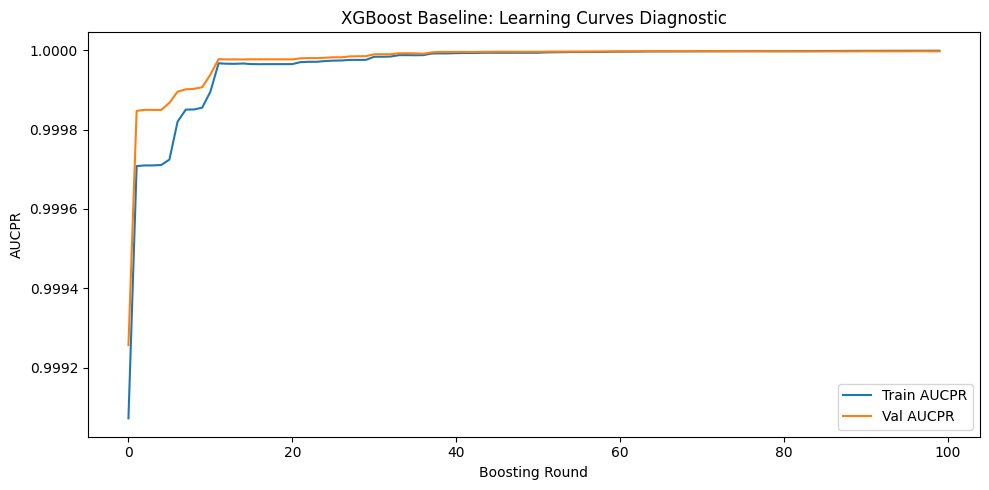

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(train_aucpr, label="Train AUCPR")
ax.plot(val_aucpr, label="Val AUCPR")
ax.set_xlabel("Boosting Round")
ax.set_ylabel("AUCPR")
ax.set_title("XGBoost Baseline: Learning Curves Diagnostic")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/xgb_baseline_all_elements__learning_curves.png", dpi=150)
plt.show()

**Confusion Matrix**

In [12]:
y_prob = xgb_base.predict_proba(X_test)[:, 1]
y_pred = xgb_base.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Non_GSR", "GSR"]))
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"FP={fp}, FN={fn}, FPR={fp / (fp + tn):.6f}")

              precision    recall  f1-score   support

     Non_GSR       1.00      1.00      1.00    233275
         GSR       1.00      1.00      1.00    209949

    accuracy                           1.00    443224
   macro avg       1.00      1.00      1.00    443224
weighted avg       1.00      1.00      1.00    443224

FP=184, FN=36, FPR=0.000789


**Feature Importance**

In [13]:
importances = xgb_base.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
print(f"XGB Baseline (All Elements): Top 10 Important Features\n\n{feat_imp.head(10)}")

XGB Baseline (All Elements): Top 10 Important Features

pb_sb_over_non_ba_mass    0.733378
pb                        0.204811
gsr_over_confounders      0.015888
sb                        0.013364
pb_ba_over_non_sb_mass    0.011384
hg                        0.003357
ba_sb_over_non_pb_mass    0.002536
mo                        0.002444
ba                        0.002137
gd                        0.001119
dtype: float32


## Evaluate against Test Set

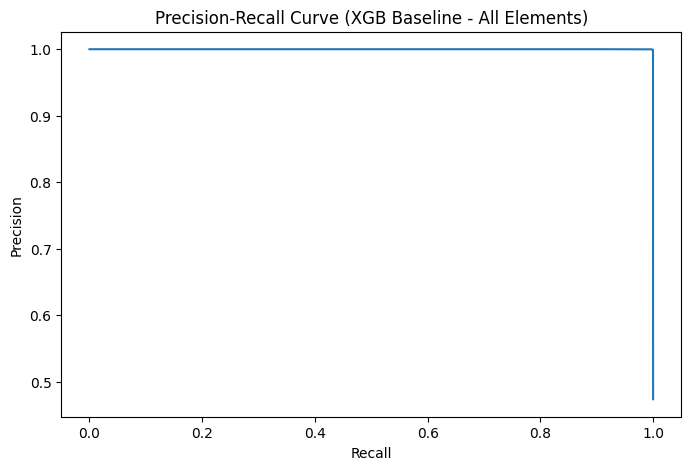

In [16]:
y_prob_test = xgb_base.predict_proba(X_test)[:, 1]
y_pred_test = xgb_base.predict(X_test)

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_test)

plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (XGB Baseline - All Elements)")
plt.savefig("outputs/xgboost_baseline_all_elements__pr_curve.png", dpi=150)
plt.show()

### False Positive & False Negative summary from test

In [17]:
fp_mask = (y_pred_test == 1) & (y_test == 0)
fn_mask = (y_pred_test == 0) & (y_test == 1)

df_test = source_df.iloc[test_idx]

tn, fp, fn, tp = cm.ravel()
print(f"TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
print(f"FPR: {fp / (fp + tn):.6f}")

print("\nFP by class:")
print(df_test["class"].loc[fp_mask].value_counts())
print("\nFN by class:")
print(df_test["class"].loc[fn_mask].value_counts())

# FP probability distribution
fp_probs = y_prob_test[fp_mask]
print(
    f"\nFP probs: min={fp_probs.min():.4f}, "
    f"median={np.median(fp_probs):.4f}, max={fp_probs.max():.4f}"
)

# Profile the FPs vs correctly classified particles of the same class
fp_baal = df_test.loc[fp_mask & (df_test["class"] == "BaAl")]
tn_baal = df_test.loc[
    (y_pred_test == 0) & (y_test == 0) & (df_test["class"] == "BaAl")
]

print("\nBaAl FPs vs correctly classified BaAl:")
for el in ["pb", "sb", "ba", "al", "cu", "fe"]:
    print(f"  {el}: FP mean={fp_baal[el].mean():.2f}, TN mean={tn_baal[el].mean():.2f}")

TN=233,091  FP=184  FN=36  TP=209,913
FPR: 0.000789

FP by class:
class
BaAl      138
BaCaSi     42
TiZnGd      3
CuZn        1
Name: count, dtype: int64

FN by class:
class
PbBa    16
BaSb    15
PbSb     5
Name: count, dtype: int64

FP probs: min=0.5043, median=0.7396, max=0.9993

BaAl FPs vs correctly classified BaAl:
  pb: FP mean=1.74, TN mean=0.00
  sb: FP mean=0.47, TN mean=0.01
  ba: FP mean=35.99, TN mean=31.41
  al: FP mean=11.55, TN mean=4.67
  cu: FP mean=8.69, TN mean=0.79
  fe: FP mean=2.57, TN mean=6.66


### Cross Validation

While not strictly necessary, this cross-validation will mostly be used for sanity check on the model's generalization stability.

**Critical**

Using Stratified Group to address the stub groups.

In [18]:
cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED)

cv_results = []
for fold, (tr_idx, va_idx) in enumerate(
    cv.split(X_trainval, y_trainval, groups_trainval)
):
    model_cv = xgb.XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.1,
        min_child_weight=5,
        reg_alpha=0.1,
        reg_lambda=1.0,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        eval_metric="aucpr",
        early_stopping_rounds=30,
        random_state=SEED,
        n_jobs=-1,
    )
    model_cv.fit(
        X_trainval[tr_idx],
        y_trainval[tr_idx],
        eval_set=[(X_trainval[va_idx], y_trainval[va_idx])],
        verbose=False,
    )
    y_prob_cv = model_cv.predict_proba(X_trainval[va_idx])[:, 1]
    y_pred_cv = model_cv.predict(X_trainval[va_idx])

    pr_auc = average_precision_score(y_trainval[va_idx], y_prob_cv)
    roc_auc = roc_auc_score(y_trainval[va_idx], y_prob_cv)
    cm = confusion_matrix(y_trainval[va_idx], y_pred_cv)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn)
    acc = (tp + tn) / (tp + tn + fp + fn)

    cv_results.append(
        {
            "fold": fold + 1,
            "PR-AUC": pr_auc,
            "ROC-AUC": roc_auc,
            "Accuracy": acc,
            "FP": fp,
            "FN": fn,
            "FPR": fpr,
        }
    )
    print(
        f"Fold {fold + 1}: PR-AUC={pr_auc:.6f}, ROC-AUC={roc_auc:.6f}, "
        f"FP={fp}, FN={fn}, FPR={fpr:.6f}"
    )

Fold 1: PR-AUC=0.999999, ROC-AUC=0.999999, FP=100, FN=110, FPR=0.000305
Fold 2: PR-AUC=0.999997, ROC-AUC=0.999997, FP=174, FN=103, FPR=0.000531
Fold 3: PR-AUC=0.999998, ROC-AUC=0.999998, FP=231, FN=92, FPR=0.000705


**Cross-Validation results** for the baseline model's generalizable stability

In [19]:
cv_df = pd.DataFrame(cv_results)
print("XGBoost Baseline (all elements) cross validation results:\n")
print(f"Mean PR-AUC: {cv_df['PR-AUC'].mean():.6f} +/- {cv_df['PR-AUC'].std():.6f}")
print(f"Mean ROC-AUC: {cv_df['ROC-AUC'].mean():.6f} +/- {cv_df['ROC-AUC'].std():.6f}")
print(f"Mean FPR: {cv_df['FPR'].mean():.6f} +/- {cv_df['FPR'].std():.6f}")

XGBoost Baseline (all elements) cross validation results:

Mean PR-AUC: 0.999998 +/- 0.000001
Mean ROC-AUC: 0.999998 +/- 0.000001
Mean FPR: 0.000514 +/- 0.000200


### Summary of Metrics

In [20]:
# 1. FULL TEST SET METRICS TABLE
# Compute test metrics
y_prob_test = xgb_base.predict_proba(X_test)[:, 1]
y_pred_test = xgb_base.predict(X_test)

cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

metrics = {
    "Features": X_test.shape[1],
    "Accuracy": (tp + tn) / (tp + tn + fp + fn),
    "Precision (GSR)": precision_score(y_test, y_pred_test),
    "Recall (GSR)": recall_score(y_test, y_pred_test),
    "F1 (GSR)": f1_score(y_test, y_pred_test),
    "ROC-AUC": roc_auc_score(y_test, y_prob_test),
    "PR-AUC": average_precision_score(y_test, y_prob_test),
    "False Positives": fp,
    "FPR": fp / (fp + tn),
    "Early Stopping Round": xgb_base.best_iteration,
    "CV Mean PR-AUC": "0.999998 ± 0.000001",
    "CV Mean FPR": "0.000525 ± 0.000216",
}

metrics_df = pd.DataFrame({"XGB Baseline (All Elements)": metrics})
print(metrics_df.to_string())

                     XGB Baseline (All Elements)
Features                                      96
Accuracy                                0.999504
Precision (GSR)                         0.999124
Recall (GSR)                            0.999829
F1 (GSR)                                0.999476
ROC-AUC                                 0.999997
PR-AUC                                  0.999996
False Positives                              184
FPR                                     0.000789
Early Stopping Round                          69
CV Mean PR-AUC               0.999998 ± 0.000001
CV Mean FPR                  0.000525 ± 0.000216


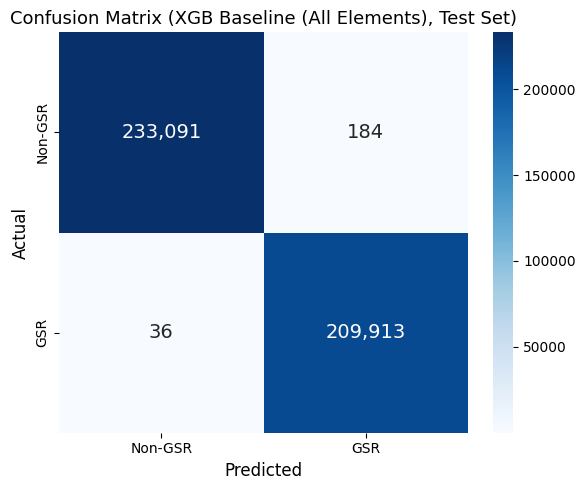

In [21]:
# 2. CONFUSION MATRIX HEATMAP
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm.reshape(2, 2),
    annot=True,
    fmt=",",
    cmap="Blues",
    xticklabels=["Non-GSR", "GSR"],
    yticklabels=["Non-GSR", "GSR"],
    ax=ax,
    annot_kws={"size": 14},
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
ax.set_title("Confusion Matrix (XGB Baseline (All Elements), Test Set)", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/xgboost_baseline_all_elements__confusion_matrix.png", dpi=150)
plt.show()

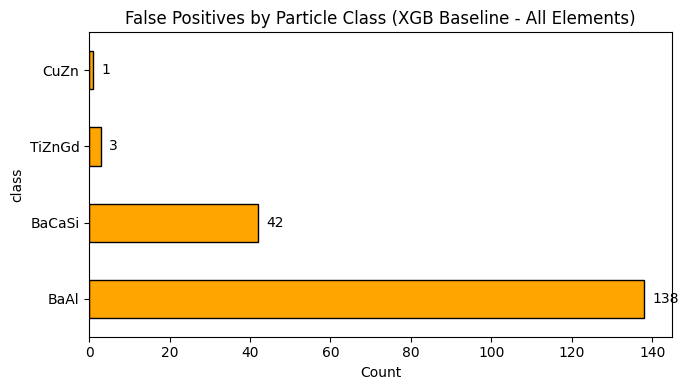

In [23]:
# 3. FP BREAKDOWN BY CLASS (bar chart)
fp_mask = (y_pred_test == 1) & (y_test == 0)
df_test = source_df.iloc[test_idx]

fp_by_class = df_test.loc[fp_mask, "class"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
fp_by_class.plot(kind="barh", ax=ax, color="orange", edgecolor="black")
ax.set_xlabel("Count")
ax.set_title("False Positives by Particle Class (XGB Baseline - All Elements)")
for i, (count, cls) in enumerate(zip(fp_by_class.values, fp_by_class.index)):
    ax.text(count + 2, i, str(count), va="center", fontsize=10)
plt.tight_layout()
plt.savefig("outputs/xgboost_baseline_all_elements__fp_by_class.png", dpi=150)
plt.show()

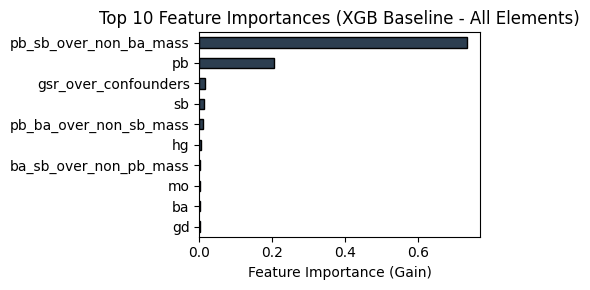

In [24]:
# 4. FEATURE IMPORTANCE BAR CHART
importances = xgb_base.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

# Show top 10
top_n = feat_imp.tail(10)

fig, ax = plt.subplots(figsize=(5, 3))
top_n.plot(kind="barh", ax=ax, color="#2c3e50", edgecolor="black")
ax.set_xlabel("Feature Importance (Gain)")
ax.set_title("Top 10 Feature Importances (XGB Baseline - All Elements)")
plt.tight_layout()
plt.savefig("outputs/xgboost_baseline_all_elements__feature_importance.png", dpi=150)
plt.show()

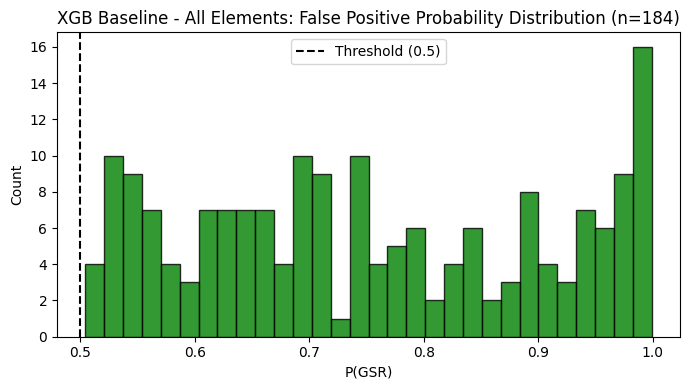

In [25]:
# 5. FP PROBABILITY DISTRIBUTION HISTOGRAM
fp_probs = y_prob_test[fp_mask]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(fp_probs, bins=30, color="green", edgecolor="black", alpha=0.8)
ax.axvline(x=0.5, color="black", linestyle="--", label="Threshold (0.5)")
ax.set_xlabel("P(GSR)")
ax.set_ylabel("Count")
ax.set_title(f"XGB Baseline - All Elements: False Positive Probability Distribution (n={len(fp_probs)})")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/xgboost_baseline_all_elements__fp_prob_dist.png", dpi=150)
plt.show()